DECISION TREE

Objective:

The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

Tasks:

1. Data Preparation:

Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).



In [134]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [135]:
file = r"heart_disease.xlsx"

df = pd.read_excel(file,sheet_name='Heart_disease')

print(df.head())

   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  



2. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.

Check for missing values, outliers, and inconsistencies in the data.

Visualize the distribution of features, including histograms, box plots, and correlation matrices.


In [136]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None


In [137]:
print(df.describe())


              age    trestbps        chol      thalch     oldpeak         num
count  908.000000  908.000000  908.000000  908.000000  846.000000  908.000000
mean    53.791850  133.430617  201.484581  135.957048    0.891253    1.008811
std      9.158031   20.401608  112.097949   26.804929    1.093875    1.144436
min     29.000000    0.000000    0.000000   60.000000   -2.600000    0.000000
25%     47.750000  120.000000  176.750000  118.000000    0.000000    0.000000
50%     54.000000  130.000000  224.000000  138.000000    0.500000    1.000000
75%     60.000000  144.000000  270.000000  156.000000    1.500000    2.000000
max     77.000000  200.000000  603.000000  202.000000    6.200000    4.000000


In [138]:
print(df.isnull().sum())


age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [139]:
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].mean())


In [140]:
print(df.isnull().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64


In [141]:
# Check for duplicate records
print(df.duplicated().sum())

1


In [142]:
# Remove duplicate records
df = df.drop_duplicates()

# Verify duplicates
print(df.duplicated().sum())

0


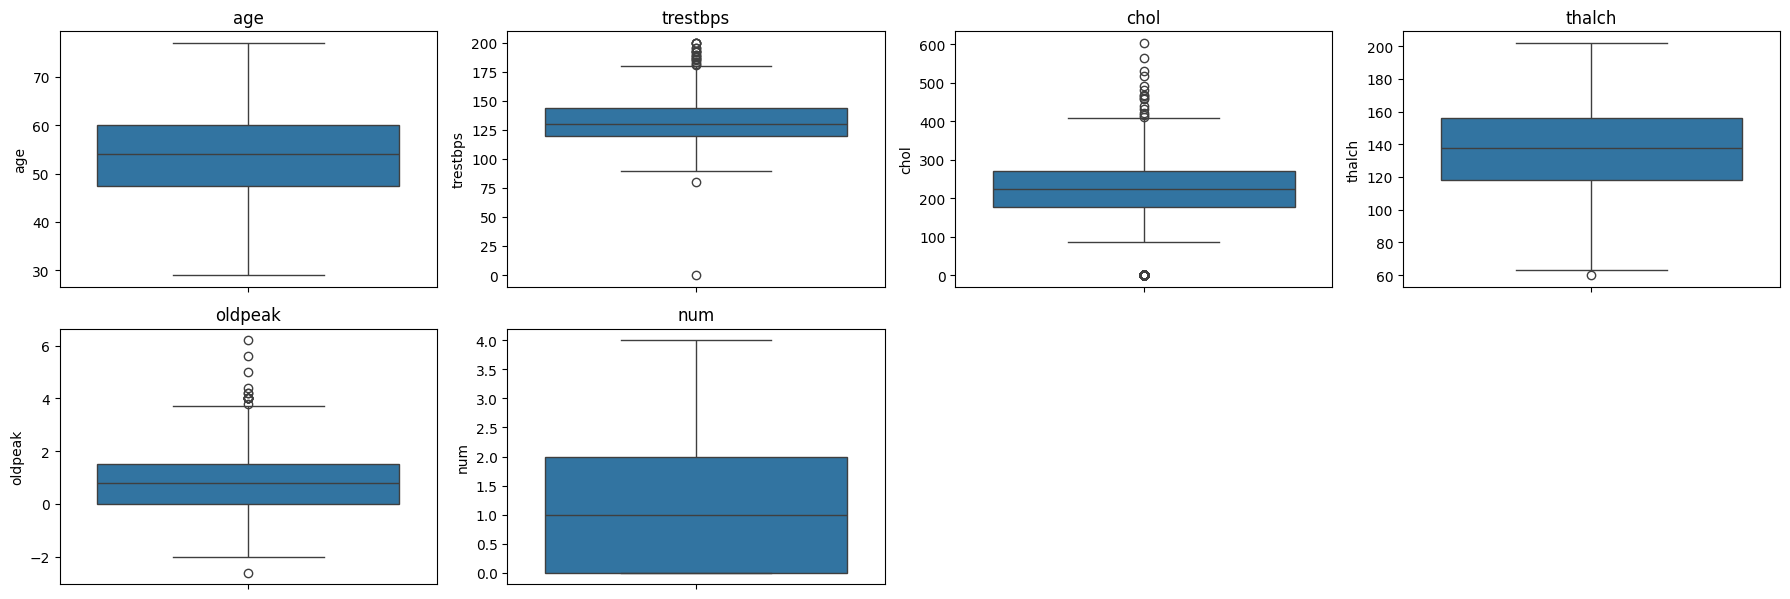

In [143]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_columns):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [144]:
# Count the number of zero values in each numerical column

(df.select_dtypes(include=['int64', 'float64']) == 0).sum()

,0
age,0
trestbps,1
chol,172
thalch,0
oldpeak,357
num,399


In [145]:
df['trestbps'] = df['trestbps'].replace(0, np.nan)
df['trestbps'].fillna(df['trestbps'].median(), inplace=True)


/tmp/ipykernel_4010/3946834171.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['trestbps'].fillna(df['trestbps'].median(), inplace=True)


In [146]:
df['chol'] = df['chol'].replace(0, np.nan)
df['chol'].fillna(df['chol'].median(), inplace=True)

/tmp/ipykernel_4010/3843958458.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['chol'].fillna(df['chol'].median(), inplace=True)


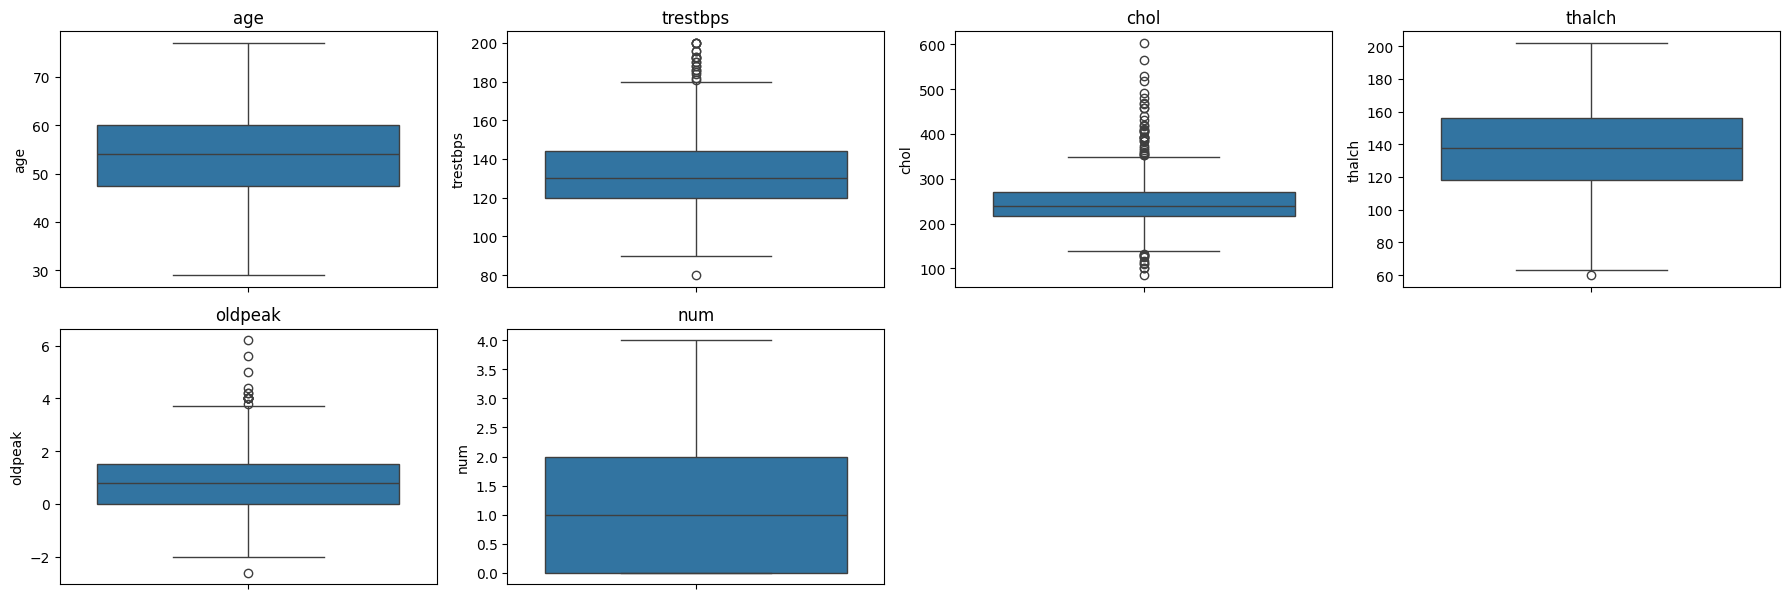

In [147]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()



3. Feature Engineering:

If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [148]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:

    if df[column].dtype == 'object' or df[column].dtype == 'bool':   #encoding categorical columns

        df[column] = df[column].astype(str)
        df[column] = le.fit_transform(df[column])


In [149]:
print(df.head())

   age  sex  cp  trestbps   chol  fbs  restecg  thalch  exang  oldpeak  slope  \
0   63    1   3     145.0  233.0    1        0     150      1      2.3      0   
1   41    1   1     135.0  203.0    0        1     132      1      0.0      1   
2   57    1   0     140.0  192.0    0        1     148      1      0.4      1   
3   52    1   3     118.0  186.0    0        0     190      1      0.0      1   
4   57    1   0     110.0  201.0    0        1     126      3      1.5      1   

   thal  num  
0     0    0  
1     0    0  
2     0    0  
3     0    0  
4     0    0  



4. Decision Tree Classification:

Split the dataset into training and testing sets (e.g., using an 80-20 split).

Implement a Decision Tree Classification model using a library like scikit-learn.

Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).


In [150]:
#define features and target
X = df.drop("num", axis=1)

y = df["num"]


In [151]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [152]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Numerical columns to scale
numerical_columns = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

# Fit on training data and transform
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

# Transform test data using the same scaler
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])


In [153]:
#decision tree model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)


In [154]:
#model training

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [155]:
#prediction
y_pred = dt_model.predict(X_test)


In [156]:
#accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)


Accuracy : 0.5384615384615384


In [157]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.70      0.85      0.77        89
           1       0.37      0.40      0.39        47
           2       0.18      0.10      0.13        20
           3       0.09      0.06      0.07        17
           4       0.00      0.00      0.00         9

    accuracy                           0.54       182
   macro avg       0.27      0.28      0.27       182
weighted avg       0.47      0.54      0.50       182



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


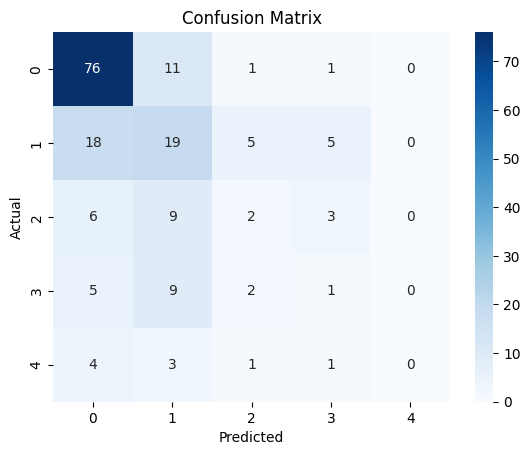

In [158]:
#confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [159]:
# ROC-AUC Score

from sklearn.metrics import roc_auc_score

# class probabilities
y_prob = dt_model.predict_proba(X_test)

# Calculate
roc_auc = roc_auc_score( y_test, y_prob, multi_class='ovr')

print("ROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.7363384353560011


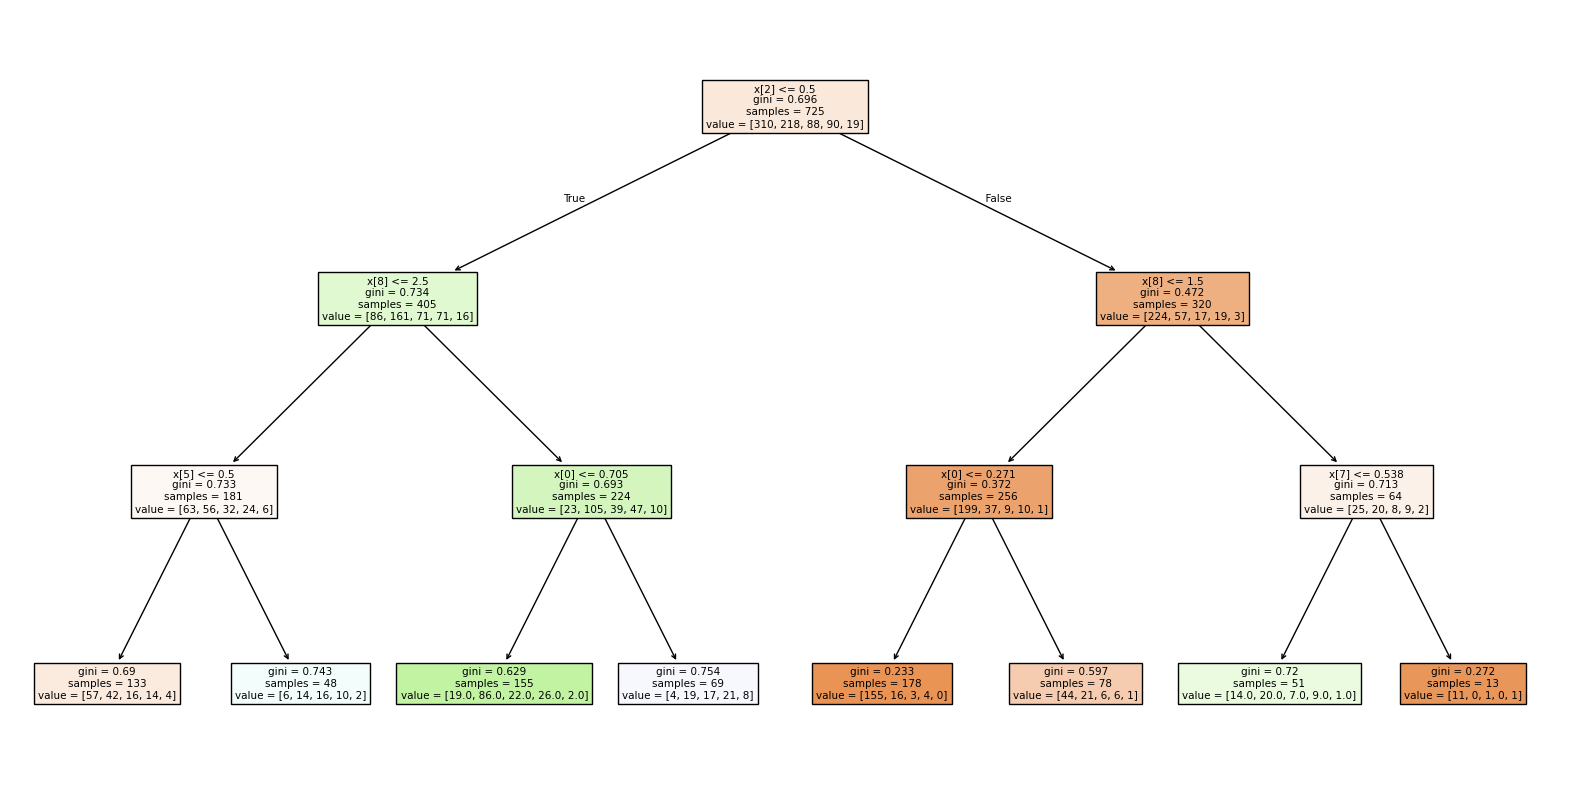

In [160]:
#decision tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_model,filled=True)

plt.show()



5. Hyperparameter Tuning:

Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


In [161]:
#feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_})

print(importance)


     Feature  Importance
0        age    0.131511
1        sex    0.000000
2         cp    0.567500
3   trestbps    0.000000
4       chol    0.000000
5        fbs    0.052884
6    restecg    0.000000
7     thalch    0.054109
8      exang    0.193996
9    oldpeak    0.000000
10     slope    0.000000
11      thal    0.000000


In [162]:
#hyperparameter tuning
for depth in [2, 3, 5, 7, 10]:

    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, pred)

    print("Max Depth :", depth)
    print("Accuracy :", accuracy)


Max Depth : 2
Accuracy : 0.5824175824175825
Max Depth : 3
Accuracy : 0.5384615384615384
Max Depth : 5
Accuracy : 0.554945054945055
Max Depth : 7
Accuracy : 0.5384615384615384
Max Depth : 10
Accuracy : 0.510989010989011


In [163]:
# Criterion

for criterion in ['gini', 'entropy']:

    model = DecisionTreeClassifier(criterion=criterion, random_state=42)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, pred)

    print("Criterion :", criterion)
    print("Accuracy :", accuracy)


Criterion : gini
Accuracy : 0.5164835164835165
Criterion : entropy
Accuracy : 0.4945054945054945


In [164]:
#Min Samples Split

for split in [2, 5, 10]:

    model = DecisionTreeClassifier(min_samples_split=split, random_state=42)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, pred)

    print("Min Samples Split :", split)
    print("Accuracy :", accuracy)


Min Samples Split : 2
Accuracy : 0.5164835164835165
Min Samples Split : 5
Accuracy : 0.532967032967033
Min Samples Split : 10
Accuracy : 0.521978021978022


In [165]:
#Max Features

for feature in [None, 'sqrt', 'log2']:

    model = DecisionTreeClassifier( max_features=feature, random_state=42)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, pred)

    print("Max Features :", feature)
    print("Accuracy :", accuracy)


Max Features : None
Accuracy : 0.5164835164835165
Max Features : sqrt
Accuracy : 0.4835164835164835
Max Features : log2
Accuracy : 0.4835164835164835



6. Model Evaluation and Analysis:

Analyse the performance of the Decision Tree model using the evaluation metrics obtained.

Visualize the decision tree structure to understand the rules learned by the model and identify important features


In [166]:
""" i tested different maximum depth values to improve performance.

   the best accuracy achieved was 57.14% with maximum depth of 3

hyperparameter tuning helps improve model performance and reduce overfitting since decision trees may over fit on complex datasets """

' i tested different maximum depth values to improve performance.\n\n   the best accuracy achieved was 57.14% with maximum depth of 3\n\nhyperparameter tuning helps improve model performance and reduce overfitting since decision trees may over fit on complex datasets '


Interview Questions:

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?


2. What is the difference between the Label encoding and One-hot encoding?


In [167]:
""" Important hyperparameters:
--- max_depth : limits how deep the tree can go
                smaller depth reduces overfitting
                larger depth increases accuracy but may overfit

--- min_samples_split : minimum number if samples required before splitting
                        higher values reduces unnecessary splits

--- min_samples_leaf : minimum samples required at a leaf node
                       helps reduce overfitting.

--- criterion : measures quality of split

--- max_features : controls number of features used for splitting
                  reduces complexity """


' Important hyperparameters:\n--- max_depth : limits how deep the tree can go\n                smaller depth reduces overfitting\n                larger depth increases accuracy but may overfit\n\n--- min_samples_split : minimum number if samples required before splitting\n                        higher values reduces unnecessary splits\n\n--- min_samples_leaf : minimum samples required at a leaf node\n                       helps reduce overfitting.\n\n--- criterion : measures quality of split\n\n--- max_features : controls number of features used for splitting\n                  reduces complexity '

In [168]:
""" Label encoding converts each category into unique integer.

One hot encoding creates separate binary column for each category """

' Label encoding converts each category into unique integer.\n\nOne hot encoding creates separate binary column for each category '